
# Problema 2 — Sistema resorte-masa sin amortiguamiento

Notebook de validación numérica para el **Problema 2** del proyecto de Matemáticas Avanzadas.

Incluye:
- solución analítica,
- Euler escalar,
- Euler matricial,
- validación de resultados,
- gráficas de comparación,
- análisis de error.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')



## 1. Parámetros del problema

Se usan los valores del ejemplo:
- $m = 1\,\mathrm{kg}$
- $k = 4\,\mathrm{N/m}$
- $x_0 = 0.5\,\mathrm{m}$
- $v_0 = 0\,\mathrm{m/s}$
- paso de Euler \(h\) configurable


In [3]:

m = 1.0
k = 4.0
x0 = 0.5
v0 = 0.0
omega = np.sqrt(k/m)
T = 2*np.pi/omega
omega, T


(np.float64(2.0), np.float64(3.141592653589793))


## 2. Solución analítica

La ecuación diferencial es

$$
x'' + \omega^2 x = 0
$$

con solución exacta

$$
x(t) = x_0 \cos(\omega t) + \frac{v_0}{\omega}\sin(\omega t)
$$


In [4]:

def exact_solution(t, x0=x0, v0=v0, omega=omega):
    return x0*np.cos(omega*t) + (v0/omega)*np.sin(omega*t)

def exact_velocity(t, x0=x0, v0=v0, omega=omega):
    return -x0*omega*np.sin(omega*t) + v0*np.cos(omega*t)

def energy(x, v, m=m, k=k):
    return 0.5*m*v**2 + 0.5*k*x**2



## 3. Método de Euler escalar

Sistema equivalente de primer orden:

$$
x' = v, \qquad v' = -\omega^2 x
$$

Recurrencias:

$$
x_{n+1} = x_n + h v_n, \qquad v_{n+1} = v_n - h \omega^2 x_n
$$
$$

In [5]:

def euler_scalar(h=0.05, t_end=3*T):
    n = int(np.floor(t_end/h))
    t = np.linspace(0, n*h, n+1)
    x = np.zeros(n+1)
    v = np.zeros(n+1)
    x[0] = x0
    v[0] = v0
    for i in range(n):
        x[i+1] = x[i] + h*v[i]
        v[i+1] = v[i] - h*(omega**2)*x[i]
    return t, x, v



## 4. Método de Euler matricial

Escribimos el sistema como

$$
\mathbf{u}' = A \mathbf{u}, \qquad
\mathbf{u} = \begin{bmatrix} x \\ v \end{bmatrix},
\quad
A = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}
$$

Euler matricial:

$$
\mathbf{u}_{n+1} = (I + hA)\mathbf{u}_n
$$




In [6]:

def euler_matrix(h=0.05, t_end=3*T):
    n = int(np.floor(t_end/h))
    t = np.linspace(0, n*h, n+1)
    u = np.zeros((n+1, 2))
    u[0, :] = [x0, v0]
    P = np.array([[1.0, h], [-h*omega**2, 1.0]])
    for i in range(n):
        u[i+1] = P @ u[i]
    return t, u[:,0], u[:,1], P



## 5. Cálculo y validación

Se comparan:
- solución exacta,
- Euler escalar,
- Euler matricial,
- error absoluto.


In [7]:

h = 0.05
t_end = 3*T

t_s, x_s, v_s = euler_scalar(h=h, t_end=t_end)
t_m, x_m, v_m, P = euler_matrix(h=h, t_end=t_end)

x_ex = exact_solution(t_s)
v_ex = exact_velocity(t_s)

err_scalar = np.abs(x_s - x_ex)
err_matrix = np.abs(x_m - x_ex)
max_diff_scalar_matrix = np.max(np.abs(x_s - x_m))
max_err = np.max(err_scalar)

summary = pd.DataFrame({
    't_s': t_s[:10],
    'x_exacta': x_ex[:10],
    'x_euler_escalar': x_s[:10],
    'x_euler_matricial': x_m[:10],
    'error_abs': err_scalar[:10]
})
summary


,t_s,x_exacta,x_euler_escalar,x_euler_matricial,error_abs
0,0.00,0.500000,0.500000,0.500000,0.000000
1,0.05,0.497502,0.500000,0.500000,0.002498
2,0.10,0.490033,0.495000,0.495000,0.004967
3,0.15,0.477668,0.485000,0.485000,0.007332
4,0.20,0.460530,0.470050,0.470050,0.009520
5,0.25,0.438791,0.450250,0.450250,0.011459
6,0.30,0.412668,0.425750,0.425750,0.013082
7,0.35,0.382421,0.396747,0.396747,0.014325
8,0.40,0.348353,0.363486,0.363486,0.015133
9,0.45,0.310805,0.326258,0.326258,0.015453



## 6. Resultados clave


In [9]:

print(f'omega = {omega:.6f} rad/s')
print(f"T = {T:.6f} s")
print(f"Matriz de Euler P ={P}")
print(f'Máxima diferencia escalar vs matricial = {max_diff_scalar_matrix:.3e}')
print(f'Error máximo absoluto = {max_err:.6f} m')


omega = 2.000000 rad/s
T = 3.141593 s
Matriz de Euler P =[[ 1.    0.05]
 [-0.2   1.  ]]
Máxima diferencia escalar vs matricial = 0.000e+00
Error máximo absoluto = 0.766681 m



## 7. Gráficas


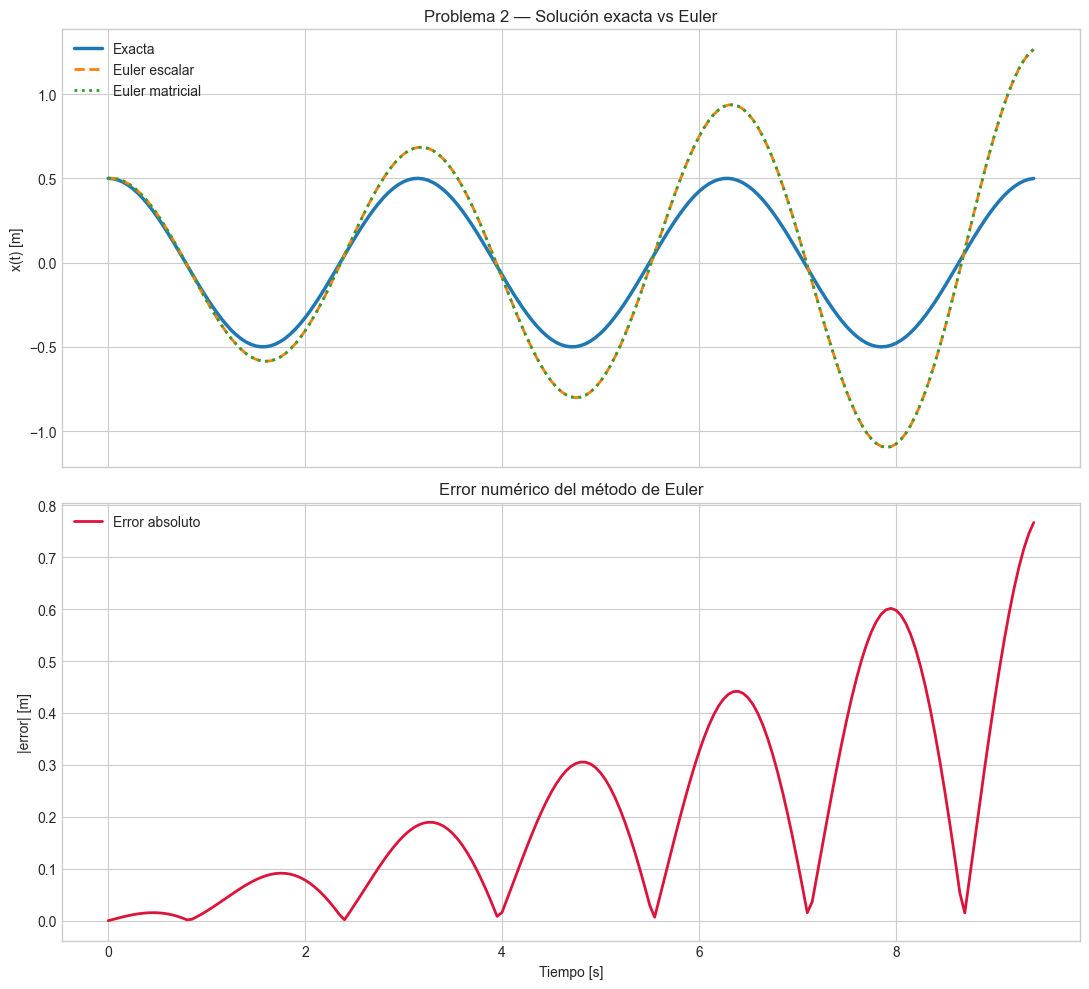

In [10]:

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

axes[0].plot(t_s, x_ex, label='Exacta', linewidth=2.5)
axes[0].plot(t_s, x_s, '--', label='Euler escalar', linewidth=2)
axes[0].plot(t_m, x_m, ':', label='Euler matricial', linewidth=2)
axes[0].set_ylabel('x(t) [m]')
axes[0].set_title('Problema 2 — Solución exacta vs Euler')
axes[0].legend()

axes[1].plot(t_s, err_scalar, label='Error absoluto', color='crimson', linewidth=2)
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('|error| [m]')
axes[1].set_title('Error numérico del método de Euler')
axes[1].legend()

plt.tight_layout()
plt.show()



## 8. Validación automática

Criterios de verificación:
1. La solución exacta satisface la ecuación diferencial.
2. Se cumplen las condiciones iniciales.
3. Euler escalar y matricial coinciden numéricamente.
4. El error es compatible con un método de orden 1.


In [11]:

# Verificación 1: ecuación diferencial
residuo = exact_solution(t_s, omega=omega)
acc = -omega**2 * exact_solution(t_s)
check_ode = np.allclose(acc + omega**2*exact_solution(t_s), 0)

# Verificación 2: condiciones iniciales
check_ic1 = np.isclose(exact_solution(0), x0)
check_ic2 = np.isclose(exact_velocity(0), v0)

# Verificación 3: equivalencia numérica
check_eq = np.allclose(x_s, x_m)

# Verificación 4: el error crece con el tiempo en Euler explícito
check_growth = err_scalar[-1] > err_scalar[1]

checks = pd.DataFrame({
    'Prueba': ['EDO', 'CI posición', 'CI velocidad', 'Escalar = matricial', 'Error creciente'],
    'Resultado': [check_ode, check_ic1, check_ic2, check_eq, check_growth]
})
checks


,Prueba,Resultado
0,EDO,True
1,CI posición,True
2,CI velocidad,True
3,Escalar = matricial,True
4,Error creciente,True



## 9. Conclusión

Este notebook valida el problema por tres vías:
- teoría analítica,
- simulación numérica,
- comparación visual y de errores.

Si el profesor pide evidencia de programación avanzada, este notebook es una excelente base para sustentación.
